# Analyse exploratoire et prétraitement des données 

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, chi2_contingency, f_oneway 
import os

In [36]:
df = pd.read_csv("./dataset/marketing_campaign.csv",sep="\t")

In [37]:
df.shape

(2240, 29)

In [38]:
df.dtypes

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [39]:
df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


In [40]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [41]:
# on a seulement 24 lignes avec des valeurs nulles, donc on peut les supprimer
df.dropna(inplace=True)
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [42]:
# convertir Dt_Customer en datetime

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],format='mixed')

## Analyse univariée:
### Variables qualitative:

In [43]:
cat_column = [col for col in df.columns if df[col].dtype == 'str']+["AcceptedCmp1",
"AcceptedCmp2",
"AcceptedCmp3",
"AcceptedCmp4",
"AcceptedCmp5",
"Response",
"Complain"]

cat_column

['Education',
 'Marital_Status',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'Response',
 'Complain']

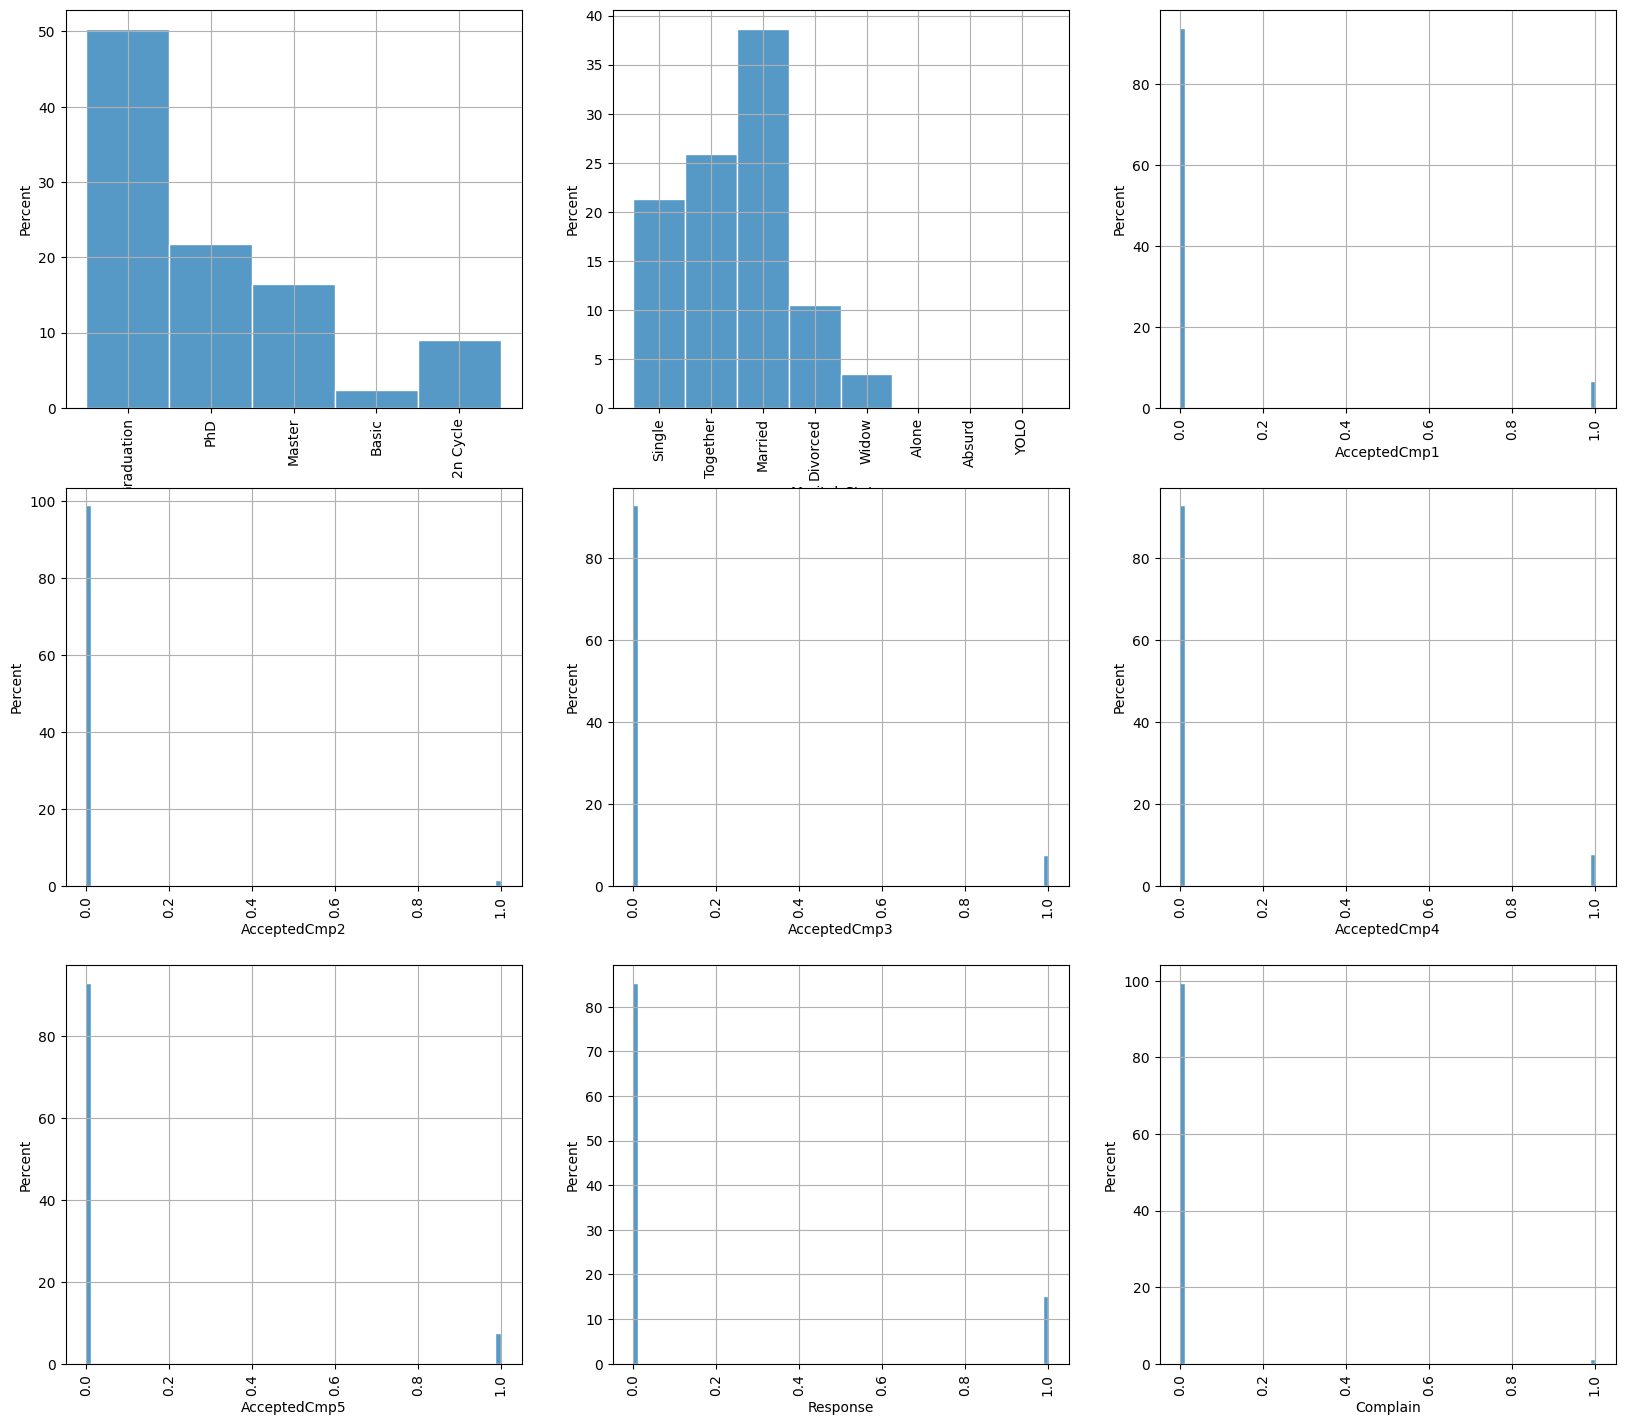

In [44]:
i = 1
plt.figure(figsize=(20,30))
for col in cat_column:
    plt.subplot(5,3,i)
    sns.histplot(x=df[col], edgecolor="white",stat="percent")
    plt.grid()
    plt.xticks(rotation=90)
    i+=1

plt.show()
    

- La majorité des clients ont gradués (50%), à peu près de 22% ont un PhD, environ 17% ont un Master, et 9% ont en 2em Cycle, et la minorité de 2% ont un niveau basique d'éducation.

- La majorité de 38.5% sont marriés, 21.5% sont célibataires, 26% together, 10% divorcés et 4% sont veufs/ves.  

Remarque: Les catégories Alone c'est la même que single, on va les fusionner, et absurd et yolo peuvent être considérés comme des valeurs aberrantes, donc on va les supprimer.

- La majorité des clients n'ont pas accepté/répondu aux campagnes anciennes (cmp1, cmp2, cmp3, cmp4), on a un peu plus de reponse pour la comagne actuelle en comparaison avec les anciennes. Le nombre de complaintes des clients est très faible.

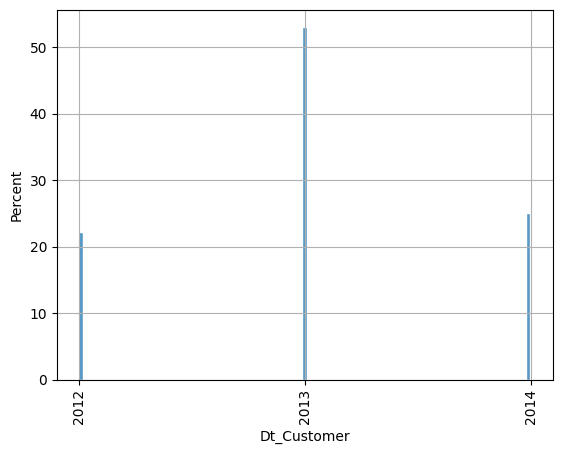

In [45]:
import matplotlib.ticker as ticker

ax=sns.histplot(x=df["Dt_Customer"].dt.year, edgecolor="white",stat="percent", shrink=0.8)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.grid()
plt.xticks(rotation=90)
plt.show()

La majorité des clients environ 53% s'ont inscrit en 2013, 25% en 2014 et 22% en 2012.

In [46]:
df["Marital_Status"] = df["Marital_Status"].replace({
    "Alone": "Single"
}) # remplacer alone avec single

df = df[~df["Marital_Status"].isin(["YOLO", "Absurd"])] # supprimer yolo et absurd

In [47]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      474
Divorced    232
Widow        76
Name: count, dtype: int64

### Variables quantitatives:

In [48]:
num_column = [
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'Z_CostContact',
 'Z_Revenue',
 ]

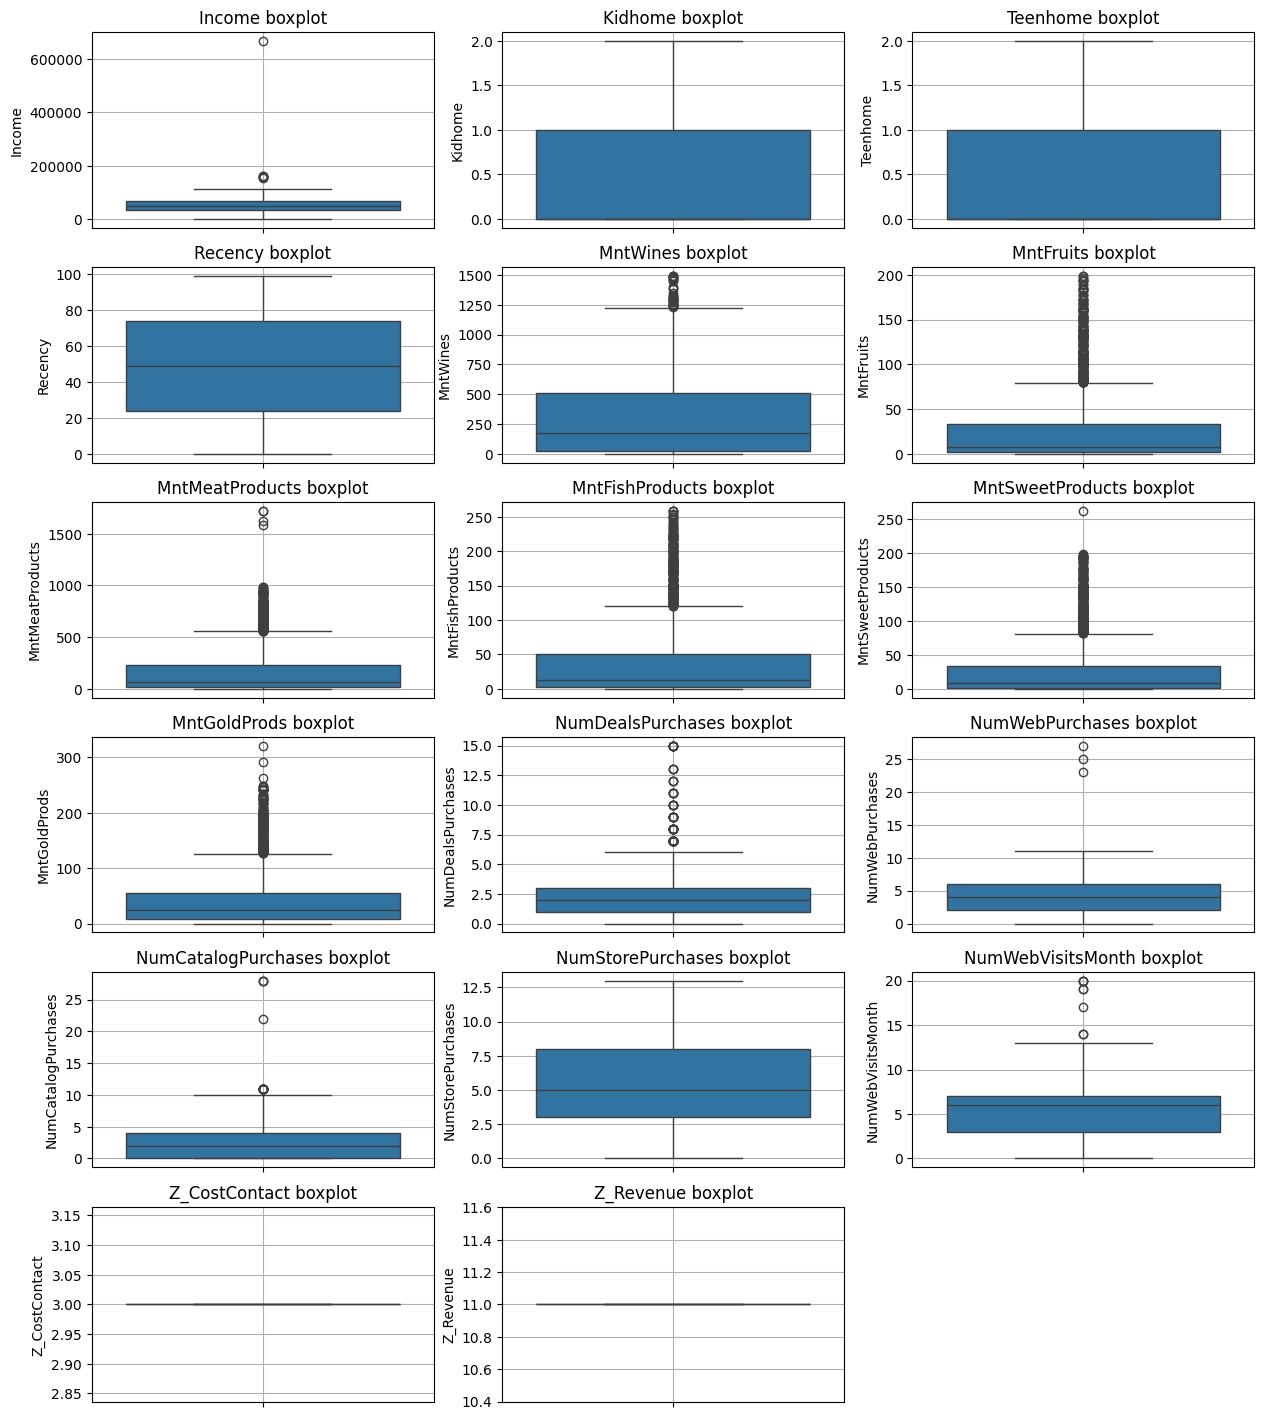

In [49]:
plt.figure(figsize=(15,30))

i=1
for col in num_column:
    plt.subplot(10,3,i)
    sns.boxplot(df[col])
    plt.title(f"{col} boxplot")
    plt.grid()
    i+=1

plt.show()

Les boxplots montrent que plusieurs variables présentent une forte dispersion ainsi que de nombreuses valeurs extrêmes (outliers), notamment les variables liées aux dépenses des clients comme `MntWines`, `MntMeatProducts`, `MntFishProducts` et `TotalSpending`. Cela signifie qu’une petite partie des clients dépense beaucoup plus que la majorité, ce qui peut correspondre à des clients premium ou à forte valeur commerciale.

La variable `Income` présente également quelques valeurs extrêmement élevées, indiquant l’existence de clients à revenus très importants. En revanche, des variables comme `Kidhome`, `Teenhome` et `Recency` sont beaucoup plus équilibrées et contiennent peu ou pas de valeurs aberrantes.

Les variables relatives aux achats (`NumWebPurchases`, `NumCatalogPurchases`, `TotalPurchases`) montrent que la majorité des clients effectuent un nombre modéré d’achats, tandis que certains clients ont une activité d’achat très élevée. De plus, les variables `Z_CostContact` et `Z_Revenue` ne présentent aucune variation, ce qui indique qu’elles sont constantes et probablement peu utiles pour la modélisation.

In [50]:
# supprimer les valeurs extrêmes en income

Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

df = df[
    (df["Income"] >= lower_bound) &
    (df["Income"] <= upper_bound)
]

In [51]:
# supprimer Z_CostContact et Z_Revenue

df.drop(['Z_CostContact','Z_Revenue'], axis=1, inplace=True)

In [52]:
num_column = [
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 ]

## Analyse bivariée:
### Deux variables qualitatives:

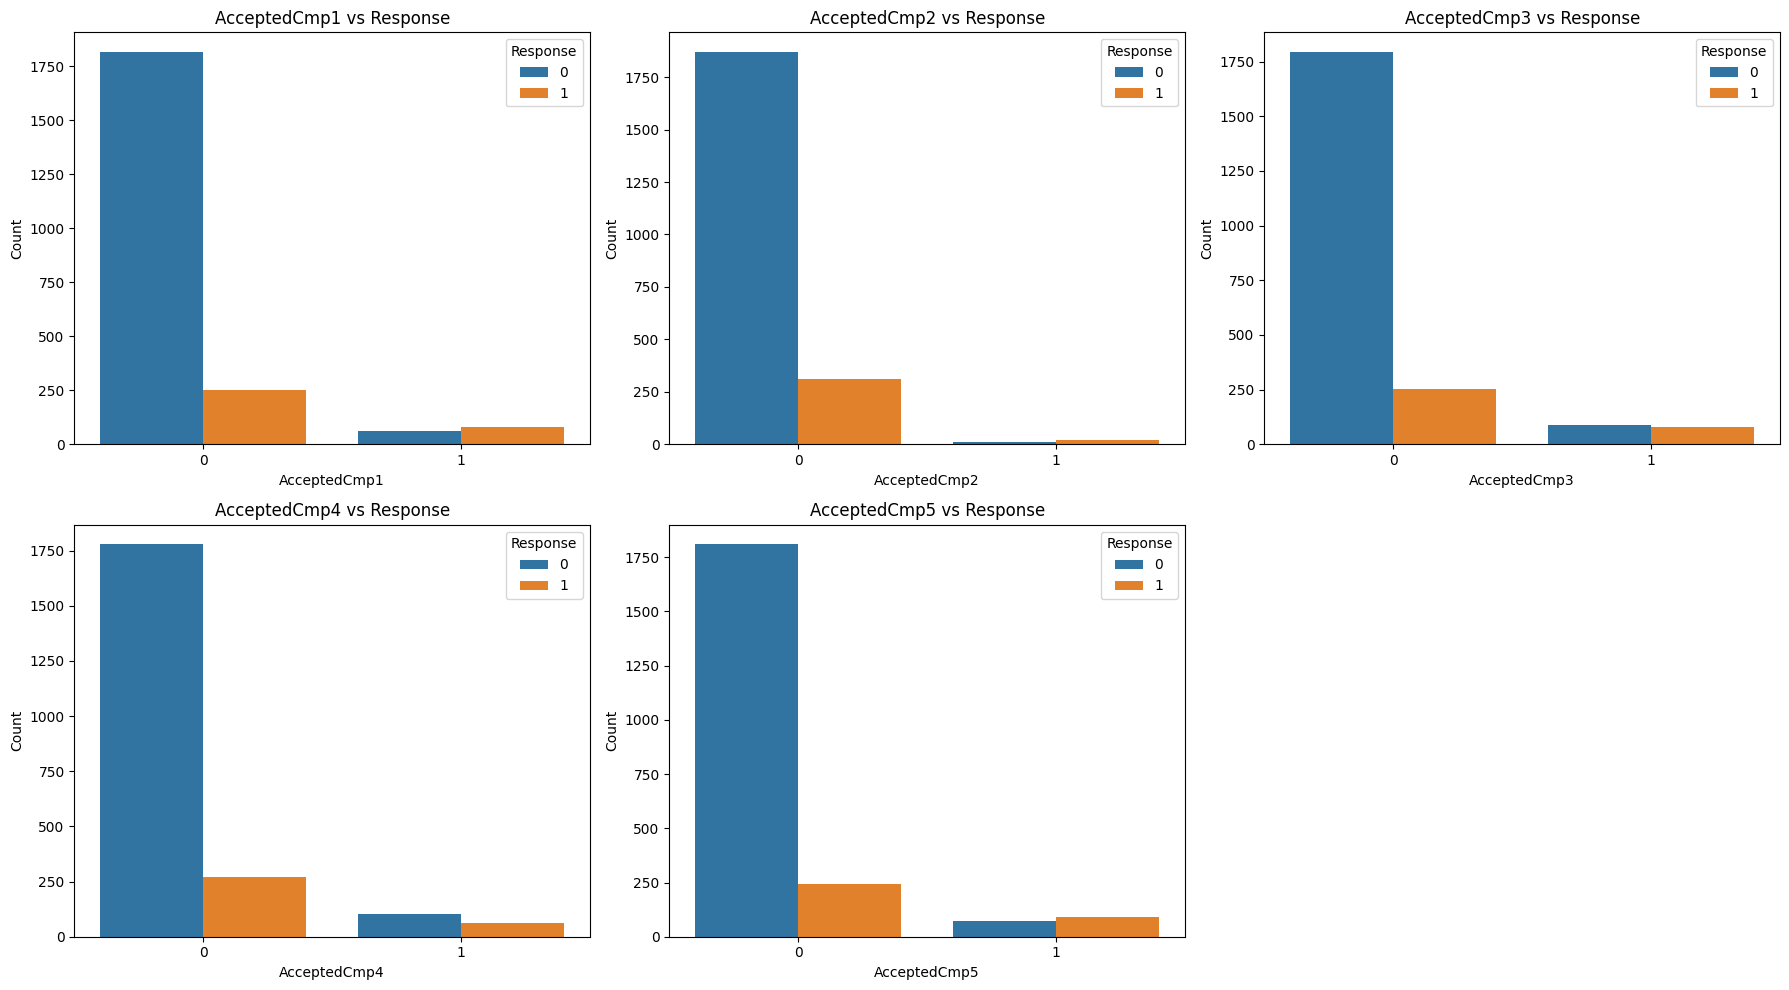

In [53]:
campaigns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(campaigns):
    
    sns.countplot(
        data=df,
        x=col,
        hue="Response",
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs Response")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# supprimer dernier subplot vide
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

Les visualisations montrent clairement que les anciennes campagnes marketing (`AcceptedCmp1` à `AcceptedCmp5`) ont une forte influence sur la réponse à la campagne actuelle (`Response`). Les clients ayant déjà accepté une campagne précédente présentent une probabilité beaucoup plus élevée de répondre positivement aux nouvelles campagnes, ce qui confirme les résultats du test du Chi² et met en évidence l’importance de l’historique d’engagement client.

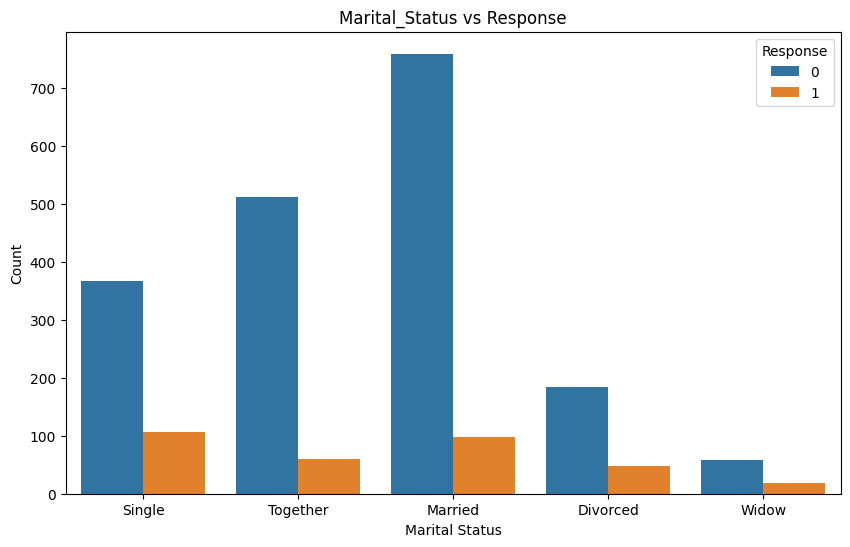

In [54]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Marital_Status",
    hue="Response"
)

plt.title("Marital_Status vs Response")
plt.xlabel("Marital Status")
plt.ylabel("Count")

plt.show()

Le graphique `Marital_Status vs Response` indique également que le statut matrimonial influence le comportement des clients. Les clients mariés et ceux vivant en couple représentent la majorité des réponses positives, probablement en raison d’un pouvoir d’achat ou d’un niveau de consommation plus élevé. Les célibataires montrent aussi un certain engagement, tandis que les catégories “Divorced” et “Widow” sont moins représentées.

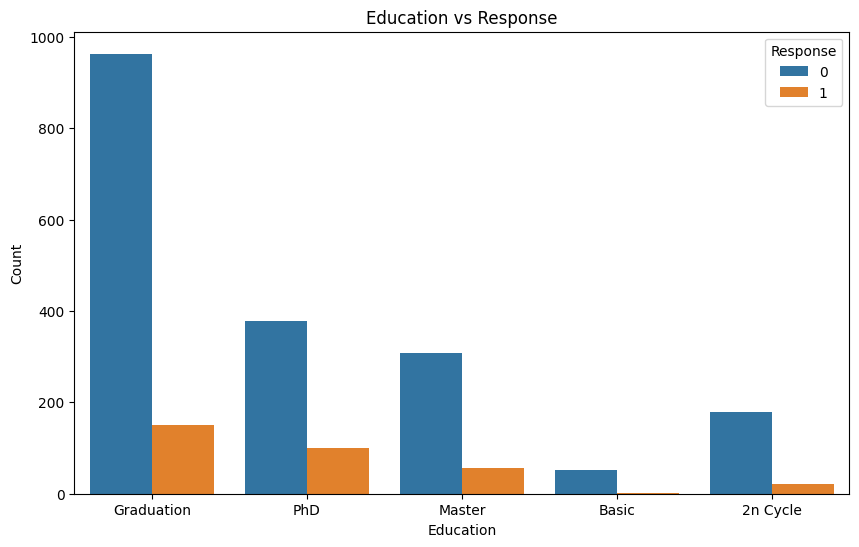

In [55]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Education",
    hue="Response"
)

plt.title("Education vs Response")
plt.xlabel("Education")
plt.ylabel("Count")

plt.show()

Concernant le niveau d’éducation, les clients ayant un niveau “Graduation”, “PhD” ou “Master” sont les plus nombreux à répondre aux campagnes marketing. Cela suggère qu’un niveau d’éducation élevé peut être associé à une plus grande sensibilité aux actions marketing et à une meilleure activité d’achat.

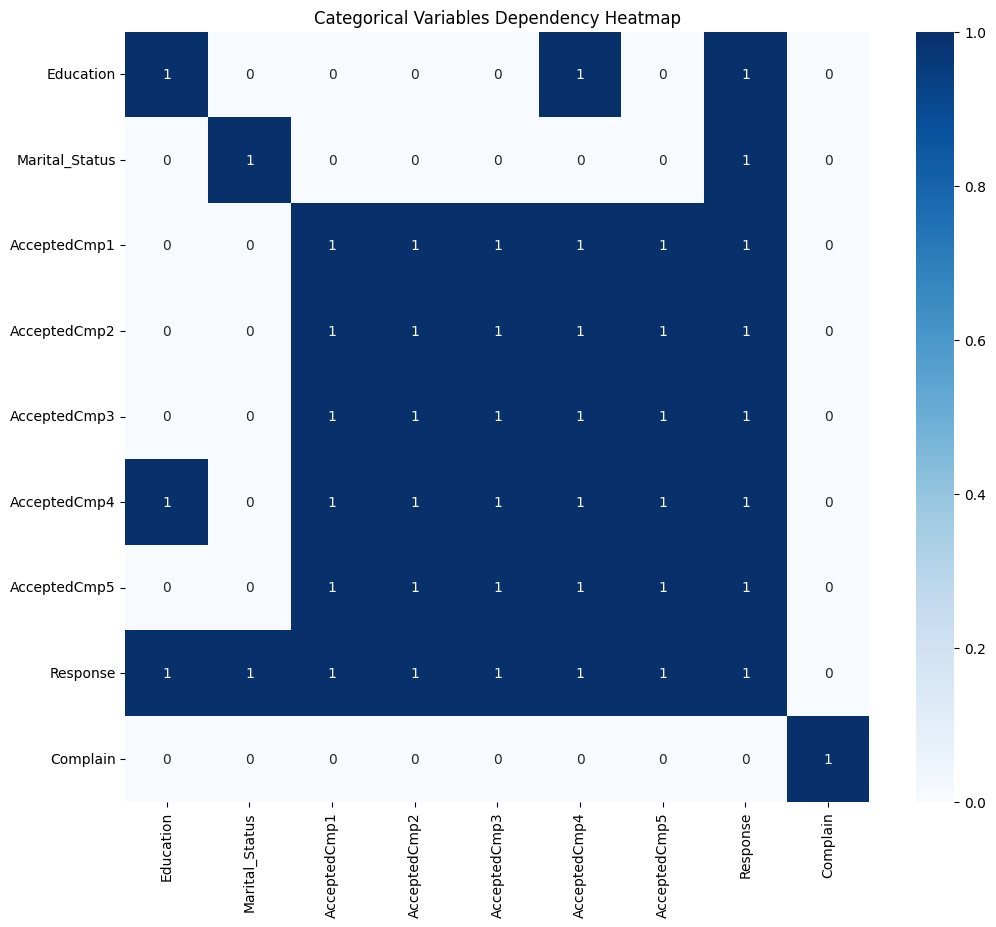

In [56]:
association_matrix = pd.DataFrame(
    np.zeros((len(cat_column), len(cat_column))),
    index=cat_column,
    columns=cat_column
)

for col1 in cat_column:
    for col2 in cat_column:
        
        contingency = pd.crosstab(df[col1], df[col2])
        
        chi2, p, dof, expected = chi2_contingency(contingency)
        
        association_matrix.loc[col1, col2] = 1 if p < 0.05 else 0

plt.figure(figsize=(12,10))

sns.heatmap(
    association_matrix,
    annot=True,
    cmap="Blues"
)

plt.title("Categorical Variables Dependency Heatmap")

plt.show()

La heatmap des dépendances catégorielles confirme statistiquement ces observations. Les variables `AcceptedCmp1` à `AcceptedCmp5` ainsi que `Response` présentent de fortes relations de dépendance entre elles, alors que la variable `Complain` apparaît indépendante des autres variables marketing. Cela montre que les anciennes campagnes constituent les indicateurs les plus pertinents pour prédire le comportement futur des clients.

### Numerical variables:

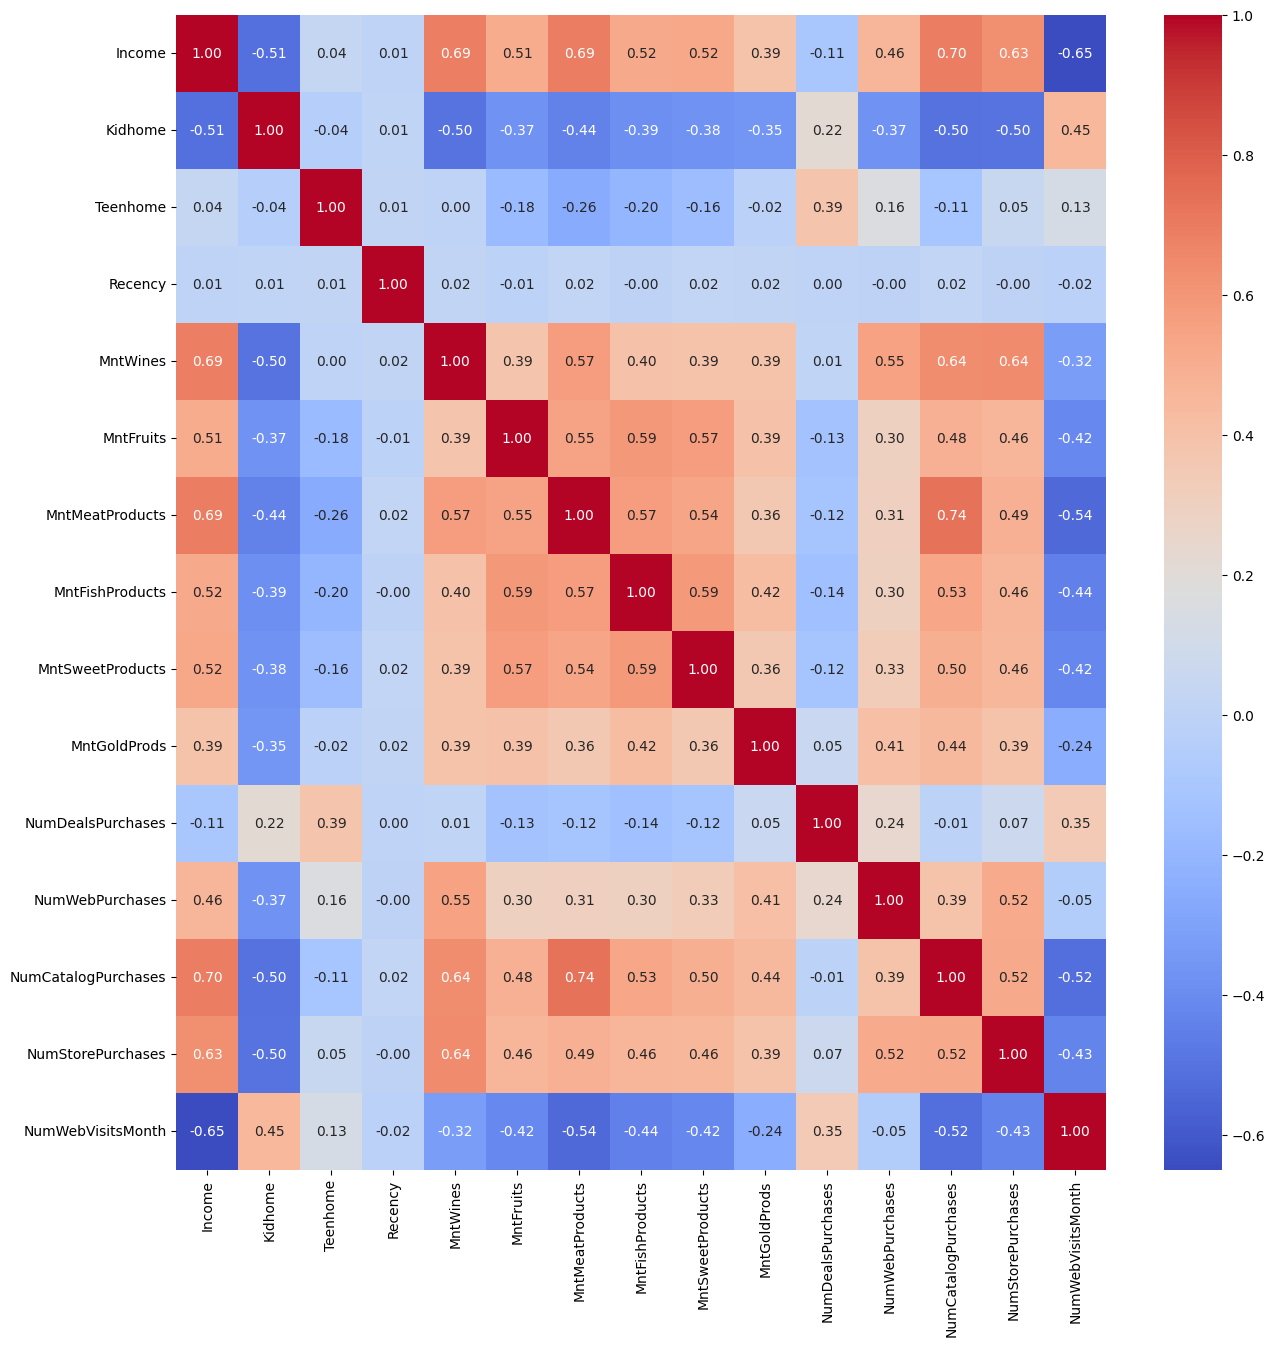

In [57]:
plt.figure(figsize=(15,15))
sns.heatmap(df[num_column].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

Cette heatmap de corrélation montre les relations linéaires entre les variables quantitatives de ton dataset. Les valeurs proches de :

+1 → forte corrélation positive,
-1 → forte corrélation négative,
0 → absence de relation.

Globalement, on observe une forte corrélation entre les variables liées aux dépenses (Mnt...) et les variables liées au nombre d’achats (Num...). Cela est logique : les clients qui achètent davantage dépensent généralement plus.

Cela indique une redondance importante d’information.

On remarque également que Income possède une corrélation positive avec les dépenses et les achats, ce qui signifie que les clients à revenus élevés ont tendance à consommer davantage. À l’inverse, NumWebVisitsMonth présente des corrélations négatives avec les dépenses et les achats, ce qui peut suggérer que certains clients visitent souvent le site sans forcément acheter.

La variable Recency présente des corrélations très faibles avec presque toutes les variables, ce qui indique qu’elle apporte une information relativement indépendante du reste des comportements d’achat.

### Categorical & numerical variables:

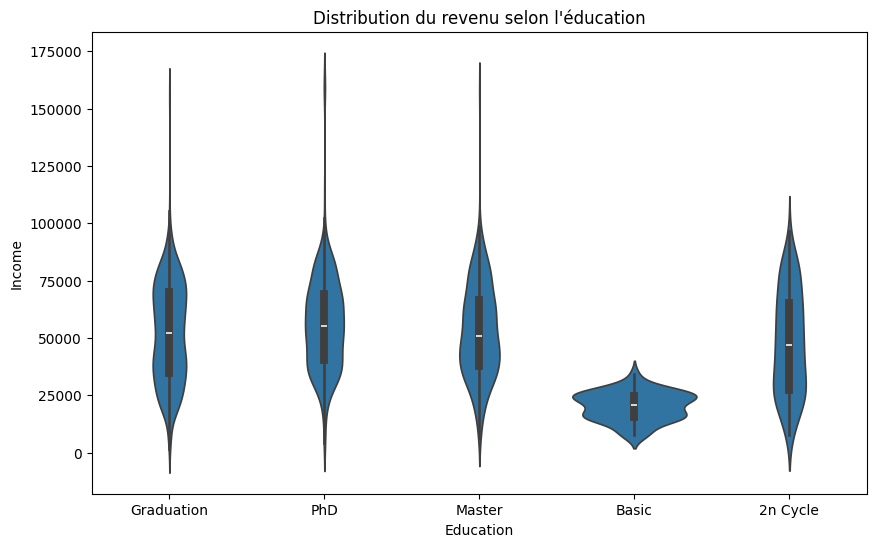

In [58]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="Education",
    y="Income"
)

plt.title("Distribution du revenu selon l'éducation")

plt.show()

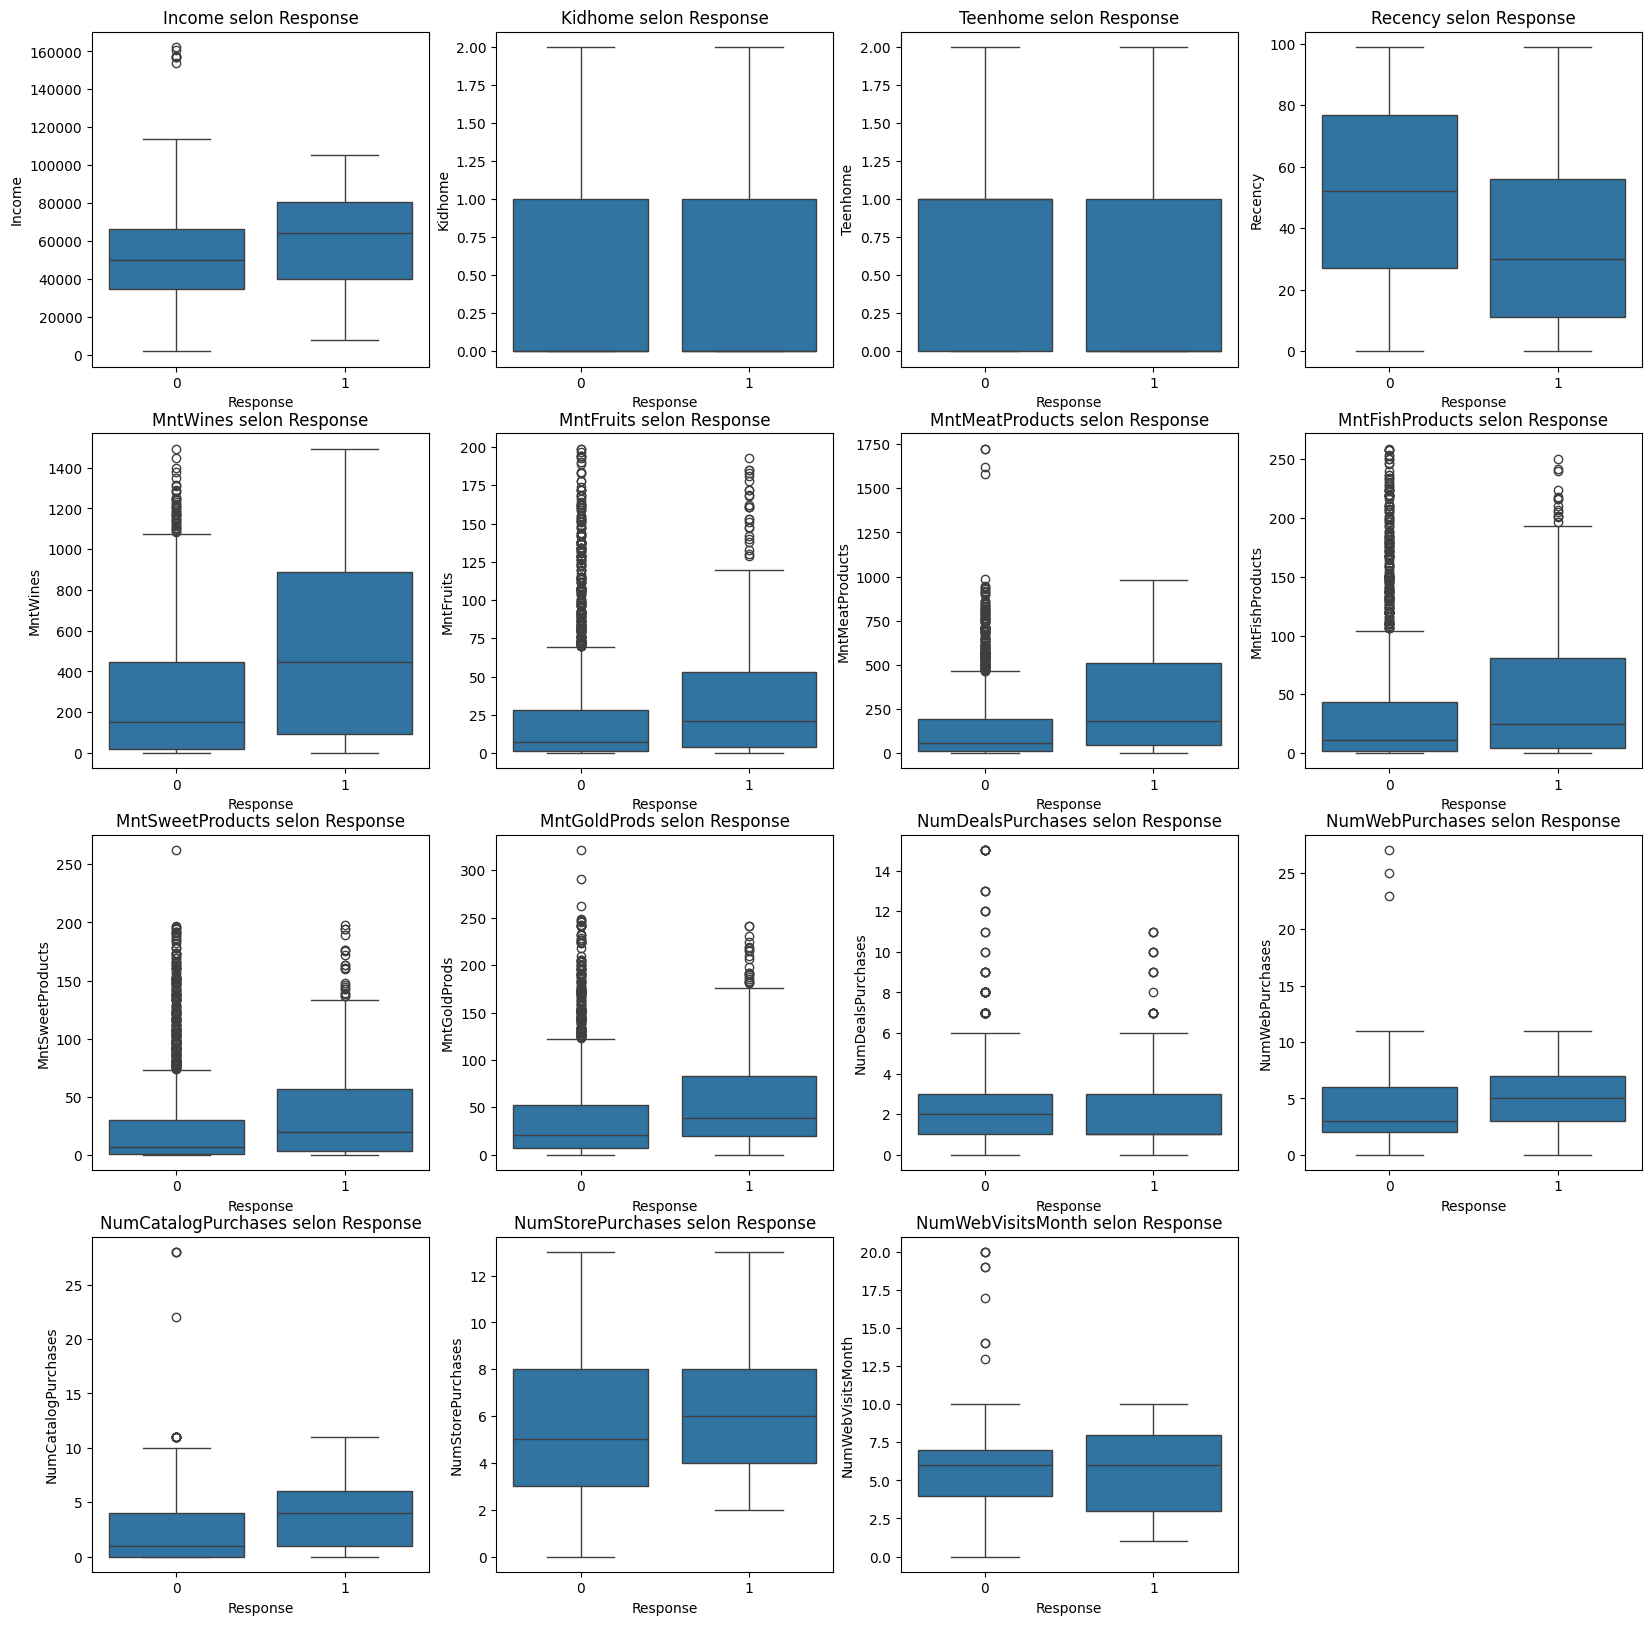

In [59]:
plt.figure(figsize=(20,20))

i=1
for num_var in num_column:

    plt.subplot(4,4,i)

    sns.boxplot(
        data=df,
        x="Response",
        y=num_var
    )

    plt.title(f"{num_var} selon Response")
    i+=1

plt.show()


Les clients ayant répondu positivement à la campagne marketing présentent globalement des revenus plus élevés que les autres clients et un niveau de dépense global plus élevé, ce qui montre que les campagnes ciblent principalement les clients à forte valeur commerciale.

Les clients actifs sur les achats en ligne répondent davantage aux campagnes marketing.

Les clients réalisant fréquemment des achats via catalogue ou en magasin présentent une probabilité légèrement élevée de répondre aux campagnes marketing.

Les clients visitant fréquemment le site web sans nécessairement acheter peuvent représenter des prospects potentiels nécessitant des campagnes de conversion plus ciblées.

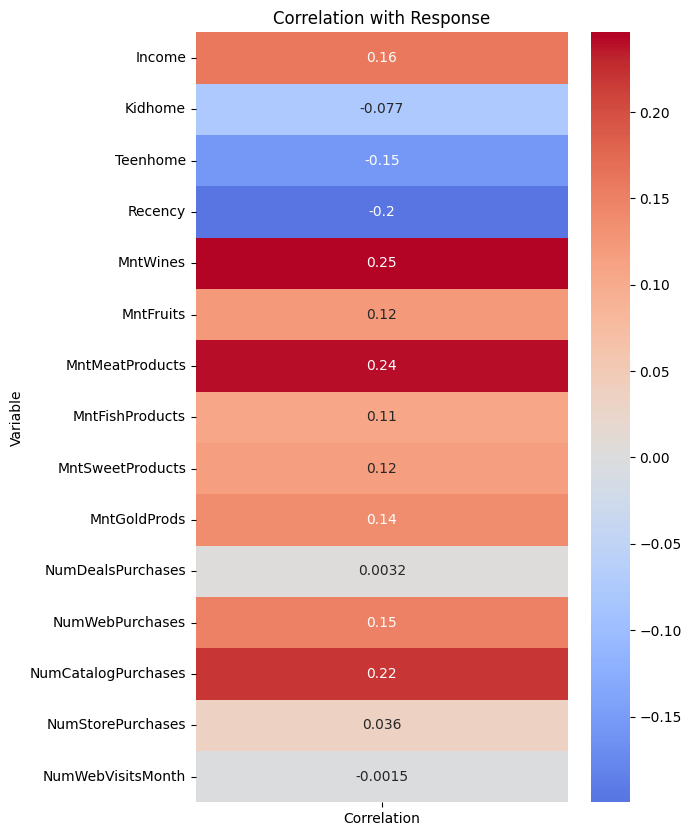

In [60]:
from scipy.stats import pointbiserialr

corr_values = []

for col in num_column:
    
    corr, p = pointbiserialr(df["Response"], df[col])
    
    corr_values.append(corr)

corr_df = pd.DataFrame({
    "Variable": num_column,
    "Correlation": corr_values
})

corr_df = corr_df.set_index("Variable")

plt.figure(figsize=(6,10))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation with Response")

plt.show()

L’analyse des corrélations met en évidence que les variables liées aux dépenses et aux achats constituent les meilleurs indicateurs de réponse aux campagnes marketing. Les clients à forte consommation et réalisant davantage d’achats en ligne ou par catalogue présentent une probabilité plus élevée d’engagement marketing. À l’inverse, certaines variables comportementales comme le nombre de visites web mensuelles montrent une influence limitée sur la variable cible

In [61]:
df.shape

(2211, 27)

In [62]:
df.to_csv("dataset/marketing_campaign_traited.csv")